# Detecção de fadiga em corrida com IMUs — exploração inicial

Dataset 4TU [doi:10.4121/14307743.v1](https://doi.org/10.4121/14307743.v1) —
Marotta et al., *Sensors* 2021;21(10):3451
([texto completo](https://pmc.ncbi.nlm.nih.gov/articles/PMC8156769/)).

8 corredores, três aquisições por sujeito com um traje inercial Xsens MVN
(8 IMUs, 240 Hz):

| arquivo | corrida | voltas | classe |
|---|---|---|---|
| `pXXX_HDSL_<CW/CCW>_0-2k.mat` | 4000 m, 1ª metade | 1–5 | `none` (0) — usa voltas 2–4 |
| `pXXX_HDSL_<CW/CCW>_2-4k.mat` | 4000 m, 2ª metade | 6–10 | `mild` (1) — usa voltas 8–10 |
| `pXXX_HDSL_postfatigue1200m.mat` | 1200 m pós-fadiga | 11–13 | `heavy` (2) |
| `pXXX_strides.mat` | passadas normalizadas no tempo (todas as corridas) | — | sem rótulo |
| `TableFeats.mat` | tabela de *features* dos autores, já normalizada | — | tem rótulo |

O protocolo de fadiga em si (2ª corrida) **não** é distribuído.

Este notebook faz quatro coisas: (1) inventaria os arquivos, (2) monta um
**glossário** dos rótulos, canais e das 165 colunas da `TableFeats`,
(3) explora a `TableFeats` — o caminho mais rápido até um baseline — e (4) abre
um sinal bruto e um arquivo de passadas para ver com o que estamos lidando.

A leitura fica toda em `src/` (ver [NOTES.md](../NOTES.md)); aqui só analisamos.

In [1]:
import os
import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# O notebook vive em notebooks/, mas src.find_data_dir() e src.PREPROCESSED
# resolvem caminhos relativos à raiz do projeto — então trabalhamos a partir dela.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

import src
from src.dataset import RECORDING_RE, RUNS, SUBJECT_ID

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 4)
pd.set_option("display.max_columns", 60)

CLASSES = {0: "none", 1: "mild", 2: "heavy"}
PALETA = {"none": "#4C9F70", "mild": "#E0A458", "heavy": "#C1666B"}

print("raiz do projeto :", ROOT)
print("dados brutos    :", src.find_data_dir())
print("sujeitos        :", ", ".join(src.subjects()))

raiz do projeto : /Users/lucasedmundo/Documents/Mack - Mestrado/ML/IMU Fatigue Detection Dataset
dados brutos    : data/raw/Dataset underlying the research on physical fatigue detection in running using inertial measurement units (IMUs)_1_all
sujeitos        : p001, p002, p003, p004, p005, p006, p007, p008


## 1. Inventário dos arquivos

Só metadados de nome e tamanho — cada gravação tem 100–300 MB, então não
carregamos nada ainda.

In [2]:
linhas = []
for p in src.recording_paths():
    m = RECORDING_RE.match(p.stem)
    sujeito = f"p{m.group('subject')}"
    run = m.group("run").lower()
    condicao, classe, voltas, voltas_paper = RUNS[run]
    linhas.append({
        "arquivo": p.name,
        "sujeito": sujeito,
        "sub": SUBJECT_ID[sujeito],          # id usado na TableFeats
        "run": run,
        "direcao": m.group("direction") or "-",
        "condicao": condicao,
        "classe": classe,
        "voltas": f"{voltas[0]}-{voltas[-1]}",
        "voltas_paper": f"{voltas_paper[0]}-{voltas_paper[-1]}",
        "MB": round(p.stat().st_size / 1e6, 1),
    })

inventario = pd.DataFrame(linhas).sort_values(["sujeito", "run"], ignore_index=True)
print(f"{len(inventario)} gravações + {len(src.strides_paths())} arquivos de passadas"
      f" = {inventario['MB'].sum() / 1000:.1f} GB de gravações")
inventario

23 gravações + 8 arquivos de passadas = 5.0 GB de gravações


,arquivo,sujeito,sub,run,direcao,condicao,classe,voltas,voltas_paper,MB
0,p001_HDSL_CCW_0-2k.mat,p001,1,0-2k,CCW,none,0,1-5,2-4,210.6
1,p001_HDSL_CW_2-4k.mat,p001,1,2-4k,CW,mild,1,6-10,8-10,204.6
2,p001_HDSL_postfatigue1200m.mat,p001,1,postfatigue1200m,-,heavy,2,11-13,11-13,133.2
3,p002_HDSL_CCW_0-2k.mat,p002,5,0-2k,CCW,none,0,1-5,2-4,244.3
4,p002_HDSL_CW_2-4k.mat,p002,5,2-4k,CW,mild,1,6-10,8-10,253.4
5,p002_HDSL_postfatigue1200m.mat,p002,5,postfatigue1200m,-,heavy,2,11-13,11-13,150.6
6,p003_HDSL_CW_0-2k.mat,p003,6,0-2k,CW,none,0,1-5,2-4,282.0
7,p003_HDSL_CCW_2-4k.mat,p003,6,2-4k,CCW,mild,1,6-10,8-10,296.4
8,p003_HDSL_postfatigue1200m.mat,p003,6,postfatigue1200m,-,heavy,2,11-13,11-13,172.4
9,p004_HDSL_CCW_0-2k.mat,p004,13,0-2k,CCW,none,0,1-5,2-4,268.6


### Dois detalhes que quebram pipelines ingênuos

Ambos já documentados em `NOTES.md`, mas vale ver na tabela:

In [3]:
# 1. p007 não tem a corrida pós-fadiga: são 31 arquivos, não 32.
#    Ele contribui só 2 das 3 classes para qualquer pipeline sobre gravações.
tamanhos = inventario.pivot_table(index="sujeito", columns="run", values="MB")
display(tamanhos)

# 2. O token CW/CCW não é posicional: em p003, p006 e p008 a 1ª metade foi CW
#    e a 2ª CCW — o inverso dos outros cinco. Sempre parseie o token da corrida.
inventario.pivot_table(index="sujeito", columns="run", values="direcao",
                       aggfunc="first").fillna("—")

run,0-2k,2-4k,postfatigue1200m
sujeito,,,
p001,210.6,204.6,133.2
p002,244.3,253.4,150.6
p003,282.0,296.4,172.4
p004,268.6,268.7,158.9
p005,272.1,269.7,164.9
p006,221.2,219.3,135.4
p007,258.7,258.5,NaN
p008,220.3,220.6,136.3


run,0-2k,2-4k,postfatigue1200m
sujeito,,,
p001,CCW,CW,-
p002,CCW,CW,-
p003,CW,CCW,-
p004,CCW,CW,-
p005,CCW,CW,-
p006,CW,CCW,-
p007,CCW,CW,—
p008,CW,CCW,-


## 2. Glossário — rótulos, canais e colunas

O README distribuído com o dataset documenta os canais brutos, mas **não
descreve nenhuma das 165 colunas da `TableFeats`**. O que segue combina três
fontes, e cada linha das tabelas abaixo traz a sua na coluna `fonte`:

| fonte | significado |
|---|---|
| `README` | está escrito no `README.txt` que acompanha os `.mat` |
| `paper` | está no artigo (Marotta et al. 2021) |
| `inferido` | deduzido do padrão de nomes e **conferido contra os dados** neste notebook |

Nada aqui é chute não verificado: as inferências que sustentam o resto do
notebook são testadas nas seções 2.4 e 2.5.

### 2.1 Rótulos e desenho experimental

O protocolo tem três corridas consecutivas na pista (README do dataset):

1. **4000 m (10 voltas)** a velocidade constante, fixada em 100 % da velocidade
   média do corredor na sua melhor prova de 5–10 km do ano anterior;
2. **protocolo de fadiga** — começa na mesma velocidade e acelera 0,2 km/h a
   cada 100 m; o RPE é perguntado a cada 100 m e a corrida termina quando passa
   de 16, ou aos 1200 m. **Estes dados não são distribuídos**;
3. **1200 m (3 voltas)** de volta à velocidade da primeira corrida.

O rótulo `fatigue` sai de *quais voltas* a amostra pertence, não de uma medida
fisiológica — é um rótulo por desenho experimental:

In [4]:
rotulos = pd.DataFrame([
    {"run (token do arquivo)": run, "condicao": cond, "fatigue": classe,
     "voltas da corrida": f"{v[0]}-{v[-1]}",
     "voltas usadas pelo paper": f"{vp[0]}-{vp[-1]}",
     "fonte": "paper"}
    for run, (cond, classe, v, vp) in RUNS.items()
])
display(rotulos)

# `rpe` é a escala de Borg (6-20) reportada pelo corredor: 6 = nenhum esforço,
# 20 = esforço máximo. É desfecho, não preditor — usá-lo como feature vazaria
# o rótulo.
sujeitos = pd.DataFrame({"sujeito": list(SUBJECT_ID), "sub (TableFeats)": list(SUBJECT_ID.values())})
sujeitos.T

,run (token do arquivo),condicao,fatigue,voltas da corrida,voltas usadas pelo paper,fonte
0,0-2k,none,0,1-5,2-4,paper
1,2-4k,mild,1,6-10,8-10,paper
2,postfatigue1200m,heavy,2,11-13,11-13,paper


,0,1,2,3,4,5,6,7
sujeito,p001,p002,p003,p004,p005,p006,p007,p008
sub (TableFeats),1,5,6,13,15,16,17,18


Os dois esquemas de identificação **não coincidem**: os arquivos usam
`p001…p008` e a `TableFeats` usa `sub ∈ {1,5,6,13,15,16,17,18}`. O mapeamento
acima foi estabelecido por estatura (ver `NOTES.md`) e é re-derivável com
`python -m src validate --full`.

### 2.2 Canais dos arquivos de gravação

Cada `.mat` de gravação traz dois structs: `segment` (8 segmentos corporais) e
`joint` (7 articulações), a 240 Hz, mais `COM.trial` (trajetória do centro de
massa) e `info`.

In [5]:
canais_seg = pd.DataFrame([
    {"código": s, "segmento": src.SEGMENT_LABEL[s],
     "campos usados": "acc, angvel",
     "unidades": "m/s² · rad/s", "forma": "(N, 3)", "fonte": "README"}
    for s in src.SEGMENTS
])
canais_art = pd.DataFrame([
    {"código": j, "articulação": src.JOINT_LABEL[j], "campo usado": "angle",
     "unidade": "GRAUS (o README diz rad — está errado)",
     "forma": "(N, 3)", "fonte": "README + correção"}
    for j in src.JOINTS
])
display(canais_seg)
display(canais_art)

print("campos não documentados no README:")
print("  segment.<S>: ori, pos, vel, angacc      joint.<J>: angle_XZY")

,código,segmento,campos usados,unidades,forma,fonte
0,STE,sternum,"acc, angvel",m/s² · rad/s,"(N, 3)",README
1,PEL,pelvis,"acc, angvel",m/s² · rad/s,"(N, 3)",README
2,RUL,right thigh,"acc, angvel",m/s² · rad/s,"(N, 3)",README
3,LUL,left thigh,"acc, angvel",m/s² · rad/s,"(N, 3)",README
4,RLL,right tibia,"acc, angvel",m/s² · rad/s,"(N, 3)",README
5,LLL,left tibia,"acc, angvel",m/s² · rad/s,"(N, 3)",README
6,RFO,right foot,"acc, angvel",m/s² · rad/s,"(N, 3)",README
7,LFO,left foot,"acc, angvel",m/s² · rad/s,"(N, 3)",README


,código,articulação,campo usado,unidade,forma,fonte
0,L5S1,trunk,angle,GRAUS (o README diz rad — está errado),"(N, 3)",README + correção
1,RHIP,right hip,angle,GRAUS (o README diz rad — está errado),"(N, 3)",README + correção
2,LHIP,left hip,angle,GRAUS (o README diz rad — está errado),"(N, 3)",README + correção
3,RKNE,right knee,angle,GRAUS (o README diz rad — está errado),"(N, 3)",README + correção
4,LKNE,left knee,angle,GRAUS (o README diz rad — está errado),"(N, 3)",README + correção
5,RANK,right ankle,angle,GRAUS (o README diz rad — está errado),"(N, 3)",README + correção
6,LANK,left ankle,angle,GRAUS (o README diz rad — está errado),"(N, 3)",README + correção


campos não documentados no README:
  segment.<S>: ori, pos, vel, angacc      joint.<J>: angle_XZY


**Duas correções ao README**, ambas já em `NOTES.md`:

- `joint.<J>.angle` está em **graus**, não radianos (a flexão do joelho chega a
  109°; em radianos seriam 6262°). `segment.acc` (m/s²) e `segment.angvel`
  (rad/s) estão como documentado.
- Dentro do array `(N, 3)` de ângulo, a **flexão/extensão é a coluna 2**. Para o
  joelho direito ela vai de 0 a 109°, enquanto as colunas 0 e 1 ficam dentro de
  ±14°. Confirmado abaixo, junto com os canais de passada.

### 2.3 Canais dos arquivos de passadas

`pXXX_strides.mat` traz 45 canais, cada um `(150 pontos do ciclo × n_passadas)`.
O README não descreve nenhum deles.

In [6]:
st = src.load_strides(next(p for p in src.strides_paths() if p.stem.startswith("p001")))

ART_ST = {"lankle": "tornozelo esquerdo", "rankle": "tornozelo direito",
          "lknee": "joelho esquerdo", "rknee": "joelho direito",
          "lhip": "quadril esquerdo", "rhip": "quadril direito", "trunk": "tronco"}
SEG_ST = {"lfoot": "pé esquerdo", "rfoot": "pé direito",
          "lll": "tíbia esquerda", "rll": "tíbia direita",
          "lul": "coxa esquerda", "rul": "coxa direita",
          "pelvis": "pelve", "sternum": "esterno"}
SUF_ST = {
    "X":  ("ângulo, componente X (= coluna 0 da gravação)", "graus", "inferido"),
    "Y":  ("ângulo, componente Y (= coluna 1 da gravação)", "graus", "inferido"),
    "":   ("ângulo de flexão/extensão (= coluna 2 da gravação)", "graus", "inferido"),
}
SIN_ST = {
    "nacc":   ("norma da aceleração do segmento", "m/s²", "inferido"),
    "jerk":   ("derivada da aceleração ao longo do ciclo", "não documentada", "inferido"),
    "angvel": ("velocidade angular (uma componente, com sinal)", "rad/s", "inferido"),
}

linhas = []
for a, nome in ART_ST.items():
    for suf, (o_que, un, fonte) in SUF_ST.items():
        linhas.append({"canal": a + suf, "corpo": nome, "o que é": o_que,
                       "unidade": un, "fonte": fonte})
for s, nome in SEG_ST.items():
    for sin, (o_que, un, fonte) in SIN_ST.items():
        linhas.append({"canal": f"{s}_{sin}", "corpo": nome, "o que é": o_que,
                       "unidade": un, "fonte": fonte})

canais_passada = pd.DataFrame(linhas)
assert sorted(canais_passada["canal"]) == sorted(st.names()), "nomes divergem do arquivo"
print(f"{len(canais_passada)} canais, todos batendo com os do arquivo")
canais_passada

45 canais, todos batendo com os do arquivo


,canal,corpo,o que é,unidade,fonte
0,lankleX,tornozelo esquerdo,"ângulo, componente X (= coluna 0 da gravação)",graus,inferido
1,lankleY,tornozelo esquerdo,"ângulo, componente Y (= coluna 1 da gravação)",graus,inferido
2,lankle,tornozelo esquerdo,ângulo de flexão/extensão (= coluna 2 da grava...,graus,inferido
3,rankleX,tornozelo direito,"ângulo, componente X (= coluna 0 da gravação)",graus,inferido
4,rankleY,tornozelo direito,"ângulo, componente Y (= coluna 1 da gravação)",graus,inferido
5,rankle,tornozelo direito,ângulo de flexão/extensão (= coluna 2 da grava...,graus,inferido
6,lkneeX,joelho esquerdo,"ângulo, componente X (= coluna 0 da gravação)",graus,inferido
7,lkneeY,joelho esquerdo,"ângulo, componente Y (= coluna 1 da gravação)",graus,inferido
8,lknee,joelho esquerdo,ângulo de flexão/extensão (= coluna 2 da grava...,graus,inferido
9,rkneeX,joelho direito,"ângulo, componente X (= coluna 0 da gravação)",graus,inferido


O canal **sem sufixo não é uma resultante** — é a componente de
flexão/extensão, em graus. A evidência: para o mesmo sujeito, a faixa de valores
de `<articulação>X`, `<articulação>Y` e `<articulação>` reproduz, nessa ordem,
as colunas 0, 1 e 2 do ângulo na gravação.

In [7]:
rec_ref = src.load_recording(next(p for p in src.recording_paths()
                                  if p.stem.startswith("p001") and "0-2k" in p.stem))

prova = []
for artic, canal in [("LANK", "lankle"), ("RKNE", "rknee"),
                     ("RHIP", "rhip"), ("L5S1", "trunk")]:
    a = rec_ref.angle(artic)
    for k, suf in enumerate(["X", "Y", ""]):
        c = st[canal + suf]
        prova.append({
            "articulação": artic,
            "gravação": f"angle[:, {k}]",
            "faixa (gravação)": f"[{a[:, k].min():7.1f}, {a[:, k].max():7.1f}]",
            "canal de passada": canal + suf,
            "faixa (passadas)": f"[{c.min():7.1f}, {c.max():7.1f}]",
        })
pd.DataFrame(prova)

,articulação,gravação,faixa (gravação),canal de passada,faixa (passadas)
0,LANK,"angle[:, 0]","[ -14.3, 16.4]",lankleX,"[ -17.4, 17.0]"
1,LANK,"angle[:, 1]","[ -12.0, 16.6]",lankleY,"[ -10.9, 20.4]"
2,LANK,"angle[:, 2]","[ -34.5, 40.6]",lankle,"[ -38.2, 37.4]"
3,RKNE,"angle[:, 0]","[ -5.8, 12.4]",rkneeX,"[ -5.8, 9.5]"
4,RKNE,"angle[:, 1]","[ -13.6, 12.0]",rkneeY,"[ -13.6, 14.2]"
5,RKNE,"angle[:, 2]","[ -0.3, 109.3]",rknee,"[ 5.2, 111.3]"
6,RHIP,"angle[:, 0]","[ -17.1, 6.7]",rhipX,"[ -18.1, 6.0]"
7,RHIP,"angle[:, 1]","[ -22.3, 6.4]",rhipY,"[ -19.9, 8.6]"
8,RHIP,"angle[:, 2]","[ -13.3, 66.3]",rhip,"[ -15.9, 53.0]"
9,L5S1,"angle[:, 0]","[ -4.5, 4.0]",trunkX,"[ -4.7, 4.3]"


As faixas não são idênticas porque a gravação cobre uma corrida e o arquivo de
passadas cobre as três, mas a correspondência coluna↔canal é inequívoca — veja
o joelho direito: `[-0,3 ; 109,3]` na gravação contra `[5,2 ; 111,3]` nas
passadas, enquanto `rkneeX` e `rkneeY` ficam nas faixas estreitas das colunas
0 e 1.

### 2.4 As 165 colunas da `TableFeats`

O artigo dá a contabilidade das features:

> *"A total of 157 features were extracted"* — 43 biomecânicas, 110
> estatísticas e 4 espaço-temporais.
>
> *"Mean, standard deviation (STD), inter-quartile range (IQR), skewness and
> kurtosis were selected in order to assess gait variability"*
>
> *"The four spatiotemporal features consisted of stride time and stride length,
> extracted from the left and the right gait cycle."*

165 colunas − 8 de contexto/rótulo = **157**. Isso fecha exatamente, o que já é
uma confirmação de que `src/tablefeats.py` alinhou nomes e colunas corretamente.

O esquema de nomes decorre daí:

| padrão | exemplo | leitura |
|---|---|---|
| `<evento>_<n>` | `MS_max_3` | ângulo da articulação `n` no evento da passada |
| `Difference<n>` | `Difference2` | simetria esquerda–direita, nível articular `n` |
| `SA<lado>` | `SAr` | *symmetry angle* |
| `max_acc<corpo>` | `max_acclti` | pico de \|aceleração\| |
| `max_av<corpo>` | `max_avrk` | pico de \|velocidade angular\| |
| `<descritor><articulação>` | `stdlk` | descritor estatístico do ângulo articular |
| `<descritor><segmento>` | `sdlll` | descritor da aceleração do segmento |
| `<descritor><segmento>av` | `sdlllav` | descritor da velocidade angular do segmento |
| `sp_<lado>` / `sl_<lado>` | `sp_r` | tempo / comprimento da passada |

Descritores: `mean` média, `std`/`sd` desvio-padrão, `i` IQR, `s` assimetria,
`k` curtose. Os eventos da passada são `IC` (contato inicial), `MS` (apoio
médio), `TO` (saída dos dedos), `MSW` (balanço médio) e `ESW` (fim do balanço).

In [8]:
csv = src.PREPROCESSED / "TableFeats.csv"
if csv.exists():
    feats = pd.read_csv(csv)
    print(f"lido de {csv}")
else:
    feats = src.load_tablefeats(src.find_data_dir() / "TableFeats.mat")
    print("decodificado direto do .mat")

feats["condicao"] = feats["fatigue"].map(CLASSES)
print(f"{feats.shape[0]:,} linhas × {feats.shape[1] - 1} colunas")

lido de data/preprocessed/TableFeats.csv
12,513 linhas × 165 colunas


In [9]:
# Dicionários do esquema de nomes. `descreve()` cobre TODA coluna ou falha.
CONTEXTO_DESC = {
    "fatigue":    ("rótulo",   "classe de fadiga: 0 none, 1 mild, 2 heavy", "paper"),
    "rpe":        ("rótulo",   "RPE de Borg (6-20) reportado na condição", "README"),
    "sub":        ("contexto", "id do sujeito na TableFeats (≠ pXXX dos arquivos)", "README"),
    "speed":      ("contexto", "velocidade da corrida, km/h (constante por sujeito)", "paper"),
    "HR_norm":    ("contexto", "frequência cardíaca normalizada", "inferido"),
    "weight":     ("contexto", "massa corporal, kg", "inferido"),
    "height":     ("contexto", "estatura, cm", "inferido"),
    "experience": ("contexto", "experiência em corrida, anos", "inferido"),
}
ANG_N = {"1": "tornozelo esquerdo", "2": "tornozelo direito",
         "3": "joelho esquerdo",    "4": "joelho direito",
         "5": "quadril esquerdo",   "6": "quadril direito"}
ART = {"la": "tornozelo esquerdo", "ra": "tornozelo direito",
       "lk": "joelho esquerdo",    "rk": "joelho direito",
       "lh": "quadril esquerdo",   "rh": "quadril direito"}
SEG = {"lf": "pé esquerdo",     "rf": "pé direito",
       "lll": "tíbia esquerda", "rll": "tíbia direita",
       "lul": "coxa esquerda",  "rul": "coxa direita",
       "st": "esterno",         "pv": "pelve"}
MAX_ACC = {"lf": "pé esquerdo", "rf": "pé direito", "lti": "tíbia esquerda",
           "rti": "tíbia direita", "lth": "coxa esquerda", "rth": "coxa direita"}
MAX_AV = {"la": "tornozelo esquerdo", "ra": "tornozelo direito",
          "lk": "joelho esquerdo", "rk": "joelho direito",
          "h": "quadril esquerdo (nome sem o 'l' — provável typo dos autores)",
          "rh": "quadril direito"}
EVENTO = {"IC": "contato inicial (IC)", "MS_max": "pico no apoio médio (MS)",
          "TO_min": "mínimo na saída dos dedos (TO)",
          "MSW_max": "pico no balanço médio (MSW)",
          "ESW_min": "mínimo no fim do balanço (ESW)"}
DESCRITOR = {"mean": "média", "std": "desvio-padrão", "sd": "desvio-padrão",
             "i": "IQR", "s": "assimetria", "k": "curtose"}
NIVEL = {"1": "tornozelos", "2": "joelhos", "3": "quadris"}
LADO = {"l": "esquerdo", "r": "direito"}


def descreve(c: str) -> tuple[str, str, str]:
    """(grupo, descrição, fonte) para uma coluna da TableFeats."""
    if c in CONTEXTO_DESC:
        return CONTEXTO_DESC[c]
    if m := re.fullmatch(r"(IC|MS_max|TO_min|MSW_max|ESW_min)_([1-6])", c):
        return ("biomecânica", f"ângulo do {ANG_N[m[2]]} no {EVENTO[m[1]]}", "paper")
    if m := re.fullmatch(r"Difference([123])", c):
        return ("biomecânica", f"simetria esquerda-direita — {NIVEL[m[1]]}", "inferido")
    if m := re.fullmatch(r"SA(l|r)", c):
        return ("biomecânica", f"symmetry angle, lado {LADO[m[1]]}", "inferido")
    if m := re.fullmatch(r"max_acc(lf|rf|lti|rti|lth|rth)", c):
        return ("biomecânica", f"pico de |aceleração| — {MAX_ACC[m[1]]}", "inferido")
    if c in ("max_sternum", "max_pelvis"):
        return ("biomecânica",
                f"pico de |aceleração| — {'esterno' if 'ster' in c else 'pelve'}", "inferido")
    if m := re.fullmatch(r"max_av(la|ra|lk|rk|h|rh)", c):
        return ("biomecânica", f"pico de |velocidade angular| — {MAX_AV[m[1]]}", "inferido")
    if c in ("max_avsternum", "max_avpelvis"):
        return ("biomecânica",
                f"pico de |velocidade angular| — {'esterno' if 'ster' in c else 'pelve'}", "inferido")
    if m := re.fullmatch(r"(mean|std|i|s|k)(la|ra|lk|rk|lh|rh)", c):
        return ("estatística · ângulo articular",
                f"{DESCRITOR[m[1]]} do ângulo — {ART[m[2]]}", "paper")
    if m := re.fullmatch(r"(mean|sd|i|s|k)(lf|rf|lll|rll|lul|rul|st|pv)(av)?", c):
        sinal = "velocidade angular" if m[3] else "aceleração"
        return (f"estatística · {sinal} do segmento",
                f"{DESCRITOR[m[1]]} da {sinal} — {SEG[m[2]]}", "paper")
    if m := re.fullmatch(r"(sp|sl)_(l|r)", c):
        o_que = "tempo de passada" if m[1] == "sp" else "comprimento da passada"
        return ("espaço-temporal", f"{o_que} — lado {LADO[m[2]]}", "paper")
    raise KeyError(f"coluna não coberta pelo glossário: {c}")


glossario = pd.DataFrame(
    [(c, *descreve(c)) for c in feats.columns if c != "condicao"],
    columns=["coluna", "grupo", "descrição", "fonte"],
).set_index("coluna")

CONTEXTO = list(glossario.index[glossario["grupo"].isin(["rótulo", "contexto"])])
FEATURES = [c for c in glossario.index if c not in CONTEXTO]

print(f"{len(glossario)} colunas descritas, nenhuma sem cobertura")
glossario["grupo"].value_counts().to_frame("n")

165 colunas descritas, nenhuma sem cobertura


,n
grupo,
biomecânica,43
estatística · aceleração do segmento,40
estatística · velocidade angular do segmento,40
estatística · ângulo articular,30
contexto,6
espaço-temporal,4
rótulo,2


In [10]:
# A contabilidade do artigo: 43 biomecânicas + 110 estatísticas + 4 espaço-temporais.
n_bio = (glossario["grupo"] == "biomecânica").sum()
n_est = glossario["grupo"].str.startswith("estatística").sum()
n_esp = (glossario["grupo"] == "espaço-temporal").sum()

print(f"biomecânicas    {n_bio:>4}   (artigo: 43)")
print(f"estatísticas    {n_est:>4}   (artigo: 110 = 6 articulações×5 + 8 segmentos×5×2 sinais)")
print(f"espaço-temporais{n_esp:>4}   (artigo: 4)")
print(f"total           {n_bio + n_est + n_esp:>4}   (artigo: 157)")
assert (n_bio, n_est, n_esp) == (43, 110, 4), "a contabilidade não bate com o artigo"
print("\nbate exatamente — o alinhamento nome↔coluna do decodificador está correto")

glossario.loc[glossario["fonte"] == "inferido", "descrição"].to_frame().head(30)

biomecânicas      43   (artigo: 43)
estatísticas     110   (artigo: 110 = 6 articulações×5 + 8 segmentos×5×2 sinais)
espaço-temporais   4   (artigo: 4)
total            157   (artigo: 157)

bate exatamente — o alinhamento nome↔coluna do decodificador está correto


,descrição
coluna,
experience,"experiência em corrida, anos"
weight,"massa corporal, kg"
height,"estatura, cm"
HR_norm,frequência cardíaca normalizada
Difference1,simetria esquerda-direita — tornozelos
Difference2,simetria esquerda-direita — joelhos
Difference3,simetria esquerda-direita — quadris
max_acclf,pico de |aceleração| — pé esquerdo
max_accrf,pico de |aceleração| — pé direito


In [11]:
# O glossário completo. É um DataFrame: dá para consultar coluna a coluna.
with pd.option_context("display.max_rows", 200, "display.max_colwidth", 70):
    display(glossario)

,grupo,descrição,fonte
coluna,,,
rpe,rótulo,RPE de Borg (6-20) reportado na condição,README
sub,contexto,id do sujeito na TableFeats (≠ pXXX dos arquivos),README
experience,contexto,"experiência em corrida, anos",inferido
weight,contexto,"massa corporal, kg",inferido
height,contexto,"estatura, cm",inferido
speed,contexto,"velocidade da corrida, km/h (constante por sujeito)",paper
fatigue,rótulo,"classe de fadiga: 0 none, 1 mild, 2 heavy",paper
HR_norm,contexto,frequência cardíaca normalizada,inferido
IC_1,biomecânica,ângulo do tornozelo esquerdo no contato inicial (IC),paper


In [12]:
def explica(*colunas):
    """Atalho de consulta ao glossário."""
    return glossario.loc[list(colunas)]

explica("sdlll", "HR_norm", "MS_max_3", "sl_r", "max_avh")

,grupo,descrição,fonte
coluna,,,
sdlll,estatística · aceleração do segmento,desvio-padrão da aceleração — tíbia esquerda,paper
HR_norm,contexto,frequência cardíaca normalizada,inferido
MS_max_3,biomecânica,ângulo do joelho esquerdo no pico no apoio méd...,paper
sl_r,espaço-temporal,comprimento da passada — lado direito,paper
max_avh,biomecânica,pico de |velocidade angular| — quadril esquerd...,inferido


### 2.5 Conferindo a numeração `1…6` das articulações

O índice em `IC_1`, `MS_max_3`, … é a única parte do esquema que o artigo não
resolve: ele diz que são *"six joint angles (left and right ankle, left and
right knee, left and right hip)"*, sem dar a ordem. A hipótese acima —
`1,2` tornozelos, `3,4` joelhos, `5,6` quadris, ímpar = esquerda — tem dois
apoios.

**Estrutural:** os eventos disponíveis por índice diferem, e diferem exatamente
como a biomecânica manda. Tornozelos têm IC/MS/TO; joelhos ganham MSW e ESW
(o joelho tem um pico próprio no balanço); quadris têm MSW no lugar de MS
(o quadril não tem pico de apoio médio).

In [13]:
eventos = pd.DataFrame(
    [{"índice": n, "articulação (hipótese)": ANG_N[n],
      "eventos presentes": ", ".join(
          e for e in EVENTO if f"{e}_{n}" in feats.columns)}
     for n in "123456"])
eventos

,índice,articulação (hipótese),eventos presentes
0,1,tornozelo esquerdo,"IC, MS_max, TO_min"
1,2,tornozelo direito,"IC, MS_max, TO_min"
2,3,joelho esquerdo,"IC, MS_max, TO_min, MSW_max, ESW_min"
3,4,joelho direito,"IC, MS_max, TO_min, MSW_max, ESW_min"
4,5,quadril esquerdo,"IC, TO_min, MSW_max"
5,6,quadril direito,"IC, TO_min, MSW_max"


**Empírico:** cada feature de evento deveria correlacionar mais com os
descritores estatísticos da sua própria articulação. Abaixo, para cada feature
de evento, o maior \|ρ de Spearman\| contra os 5 descritores de cada uma das 6
articulações — o `×` marca a articulação prevista pela hipótese.

a articulação prevista é a de maior correlação em 17/22 features


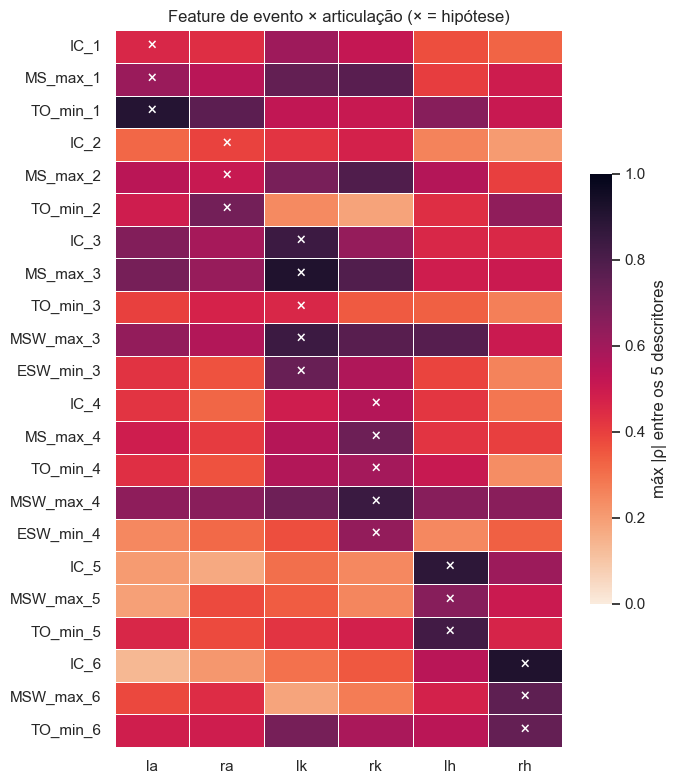

In [14]:
DESCS = ["mean", "std", "i", "s", "k"]
ev_cols = [c for c in feats.columns if re.fullmatch(r"(IC|MS_max|TO_min|MSW_max|ESW_min)_[1-6]", c)]

M = pd.DataFrame(
    {a: [max(abs(feats[c].corr(feats[d + a], method="spearman")) for d in DESCS)
         for c in ev_cols]
     for a in ART},
    index=ev_cols)

previsto = {c: list(ART)[int(c[-1]) - 1] for c in ev_cols}
marcas = np.array([[("×" if previsto[c] == a else "") for a in ART] for c in ev_cols])

fig, ax = plt.subplots(figsize=(7, 8))
sns.heatmap(M, cmap="rocket_r", vmin=0, vmax=1, annot=marcas, fmt="",
            annot_kws={"color": "w", "fontsize": 13}, linewidths=0.4,
            cbar_kws={"label": "máx |ρ| entre os 5 descritores", "shrink": 0.6}, ax=ax)
ax.set(title="Feature de evento × articulação (× = hipótese)", xlabel="", ylabel="")
plt.tight_layout()

acertos = (M.idxmax(axis=1) == pd.Series(previsto)).sum()
print(f"a articulação prevista é a de maior correlação em {acertos}/{len(ev_cols)} features")

A lateralidade e os índices `3–6` se confirmam sem ambiguidade: `MS_max_3` →
joelho esquerdo (ρ = 0,92), `IC_5` → quadril esquerdo (0,88), `IC_6` → quadril
direito (0,92).

Para `1` e `2` o argmax às vezes cai no joelho em vez do tornozelo — esperado,
porque o ângulo do tornozelo no contato inicial é fortemente acoplado ao do
joelho e os descritores são médias sobre a janela inteira. Mas no evento em que
o tornozelo é distintivo, a saída dos dedos, o sinal é limpo: `TO_min_1` →
tornozelo esquerdo (0,90) e `TO_min_2` → tornozelo direito (0,70), com a
lateralidade correta. Somado ao argumento estrutural e ao fato de que sobram
exatamente dois índices para os tornozelos, a atribuição está fechada.

## 3. `TableFeats` — explorando

12.513 passadas × 165 colunas, com rótulo `fatigue` (0/1/2) e `rpe`. É o atalho
para um baseline antes de extrair features do sinal bruto.

O `.mat` é uma `table` do MATLAB (objeto MCOS), que o scipy devolve como um stub
opaco — `src/tablefeats.py` decodifica o blob binário. As 4 colunas categóricas
do original (`footstrike`, `dir`, `gender`, `d_l`) não são recuperadas: 165
numéricas de 169 declaradas.

In [15]:
feats[CONTEXTO].head()

,rpe,sub,experience,weight,height,speed,fatigue,HR_norm
0,8,1,8.0,69.0,182.0,13.710968,0,NaN
1,8,1,8.0,69.0,182.0,13.710968,0,NaN
2,8,1,8.0,69.0,182.0,13.710968,0,NaN
3,8,1,8.0,69.0,182.0,13.710968,0,NaN
4,8,1,8.0,69.0,182.0,13.710968,0,NaN


In [16]:
faltantes = feats.isna().sum()
faltantes = faltantes[faltantes > 0]
print("colunas com ausentes:", len(faltantes))
display(faltantes.to_frame("n_ausentes"))

# Todo o buraco está num único sujeito — sem frequência cardíaca registrada.
if len(faltantes):
    col = faltantes.index[0]
    display(feats[feats[col].isna()].groupby("sub").size().to_frame("linhas sem " + col))

colunas com ausentes: 1


,n_ausentes
HR_norm,1296


,linhas sem HR_norm
sub,
1,1296


### Balanceamento e sujeitos

In [17]:
balanco = pd.crosstab(feats["sub"], feats["condicao"])[list(PALETA)]
balanco["total"] = balanco.sum(axis=1)
display(balanco)

perfil = (feats.groupby("sub")[["speed", "height", "weight", "experience", "rpe"]]
          .agg({"speed": "first", "height": "first", "weight": "first",
                "experience": "first", "rpe": "mean"})
          .rename(columns={"rpe": "rpe_medio"}).round(2))
perfil.insert(0, "sujeito", {v: k for k, v in SUBJECT_ID.items()})
display(perfil)

condicao,none,mild,heavy,total
sub,,,,
1,432,432,432,1296
5,561,561,561,1683
6,547,547,547,1641
13,587,587,587,1761
15,559,559,559,1677
16,470,470,470,1410
17,547,547,547,1641
18,468,468,468,1404


,sujeito,speed,height,weight,experience,rpe_medio
sub,,,,,,
1,p001,13.71,182.0,69.0,8.0,9.67
5,p002,11.03,164.0,55.0,3.0,11.00
6,p003,9.42,167.0,69.0,10.0,12.33
13,p004,10.11,168.0,63.5,7.5,9.33
15,p005,9.75,174.0,78.0,2.0,9.67
16,p006,11.98,187.0,77.0,0.5,13.67
17,p007,10.22,169.0,75.0,1.5,14.00
18,p008,11.97,188.0,82.0,6.0,14.33


As classes estão **exatamente balanceadas dentro de cada sujeito** (os autores
amostraram o mesmo número de passadas por condição), mas o número de passadas
varia entre sujeitos — 432 a 587. E a dispersão entre sujeitos é grande:
velocidade de 9,4 a 13,7 km/h, estatura de 164 a 188 cm. É exatamente esse
espalhamento que a normalização por sujeito existe para remover.

,mean,std,min,max
condicao,,,,
none,9.51,1.33,8,11
mild,11.49,1.84,8,14
heavy,14.08,3.41,10,19


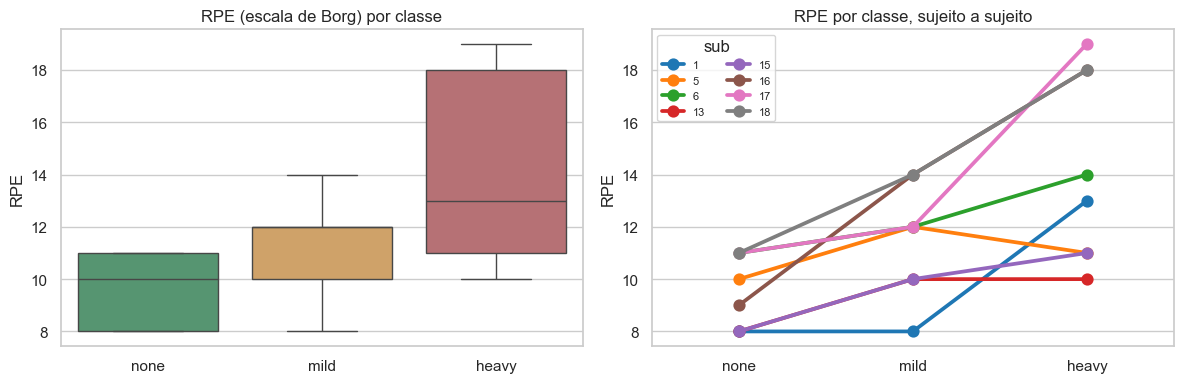

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=feats, x="condicao", y="rpe", order=list(PALETA),
            hue="condicao", palette=PALETA, legend=False, ax=axes[0])
axes[0].set(title="RPE (escala de Borg) por classe", xlabel="", ylabel="RPE")

sns.pointplot(data=feats, x="condicao", y="rpe", hue="sub", order=list(PALETA),
              errorbar=None, ax=axes[1], palette="tab10")
axes[1].set(title="RPE por classe, sujeito a sujeito", xlabel="", ylabel="RPE")
axes[1].legend(title="sub", ncol=2, fontsize=8)
plt.tight_layout()

feats.groupby("condicao", observed=True)["rpe"].agg(["mean", "std", "min", "max"]).loc[list(PALETA)].round(2)

O RPE médio sobe monotonicamente (9,5 → 11,5 → 14,1) e **em todos os oito
sujeitos** — o rótulo é consistente. Note de novo que `rpe` é desfecho, não
feature.

### Quais features separam as classes?

As features já vêm **z-scoradas por sujeito** (média 0, desvio 1 dentro de cada
`sub`), como diz o README do dataset. Isso torna a correlação de Spearman com o
rótulo uma triagem univariada barata.

IC_1      MS_max_1      TO_min_1      IC_2      MS_max_2     
    mean  std     mean  std     mean  std mean  std     mean  std
sub                                                              
1   -0.0  1.0      0.0  1.0     -0.0  1.0  0.0  1.0      0.0  1.0
5   -0.0  1.0     -0.0  1.0     -0.0  1.0  0.0  1.0     -0.0  1.0
6   -0.0  1.0      0.0  1.0     -0.0  1.0  0.0  1.0     -0.0  1.0
13  -0.0  1.0     -0.0  1.0      0.0  1.0 -0.0  1.0     -0.0  1.0
15  -0.0  1.0     -0.0  1.0     -0.0  1.0 -0.0  1.0      0.0  1.0

,spearman,descrição
sla,0.892,assimetria do ângulo — tornozelo esquerdo
sdlll,0.879,desvio-padrão da aceleração — tíbia esquerda
meanlll,0.874,média da aceleração — tíbia esquerda
sdlllav,0.866,desvio-padrão da velocidade angular — tíbia es...
sdrllav,0.861,desvio-padrão da velocidade angular — tíbia di...
sra,0.824,assimetria do ângulo — tornozelo direito
sdst,0.823,desvio-padrão da aceleração — esterno
max_acclti,0.798,pico de |aceleração| — tíbia esquerda
sdrll,0.791,desvio-padrão da aceleração — tíbia direita
meanpv,0.778,média da aceleração — pelve


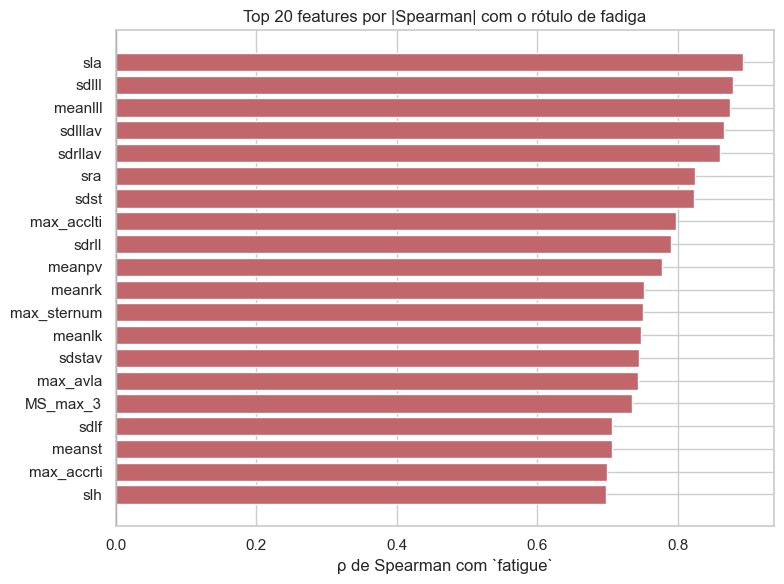

In [19]:
# Confirmando a normalização por sujeito antes de confiar na triagem.
checagem = feats.groupby("sub")[FEATURES[:5]].agg(["mean", "std"]).round(3)
display(checagem.head())

corr = (feats[FEATURES].corrwith(feats["fatigue"], method="spearman")
        .dropna().sort_values(key=abs, ascending=False))
top = corr.head(20)

fig, ax = plt.subplots(figsize=(8, 6))
cores = ["#C1666B" if v > 0 else "#4C9F70" for v in top.values]
ax.barh(top.index[::-1], top.values[::-1], color=cores[::-1])
ax.set(title="Top 20 features por |Spearman| com o rótulo de fadiga",
       xlabel="ρ de Spearman com `fatigue`")
ax.axvline(0, color="k", lw=0.8)
plt.tight_layout()

# Agora dá para ler o ranking sem decodificar nomes na cabeça.
corr.head(10).to_frame("spearman").round(3).join(glossario[["descrição"]])

> **Atenção.** Um único preditor com ρ ≈ 0,94 (`HR_norm`) e vários acima de 0,85
> é bom demais para ser um problema de classificação honesto. A causa é a
> normalização por sujeito: ela usa a distribuição do próprio sujeito **através
> das três condições**, então em avaliação *leave-one-subject-out* a estatística
> de normalização já viu os dados de teste (é transdutiva). Isso é defensável se
> a aplicação real permitir calibrar por usuário, mas precisa ser dito.
>
> Para comparação, o baseline sobre features extraídas por janelas do sinal
> bruto (registrado em `NOTES.md`) chegou a acurácia 0,694 / F1-macro 0,701 em
> LOSO — bem longe do que estes ρ sugeririam.

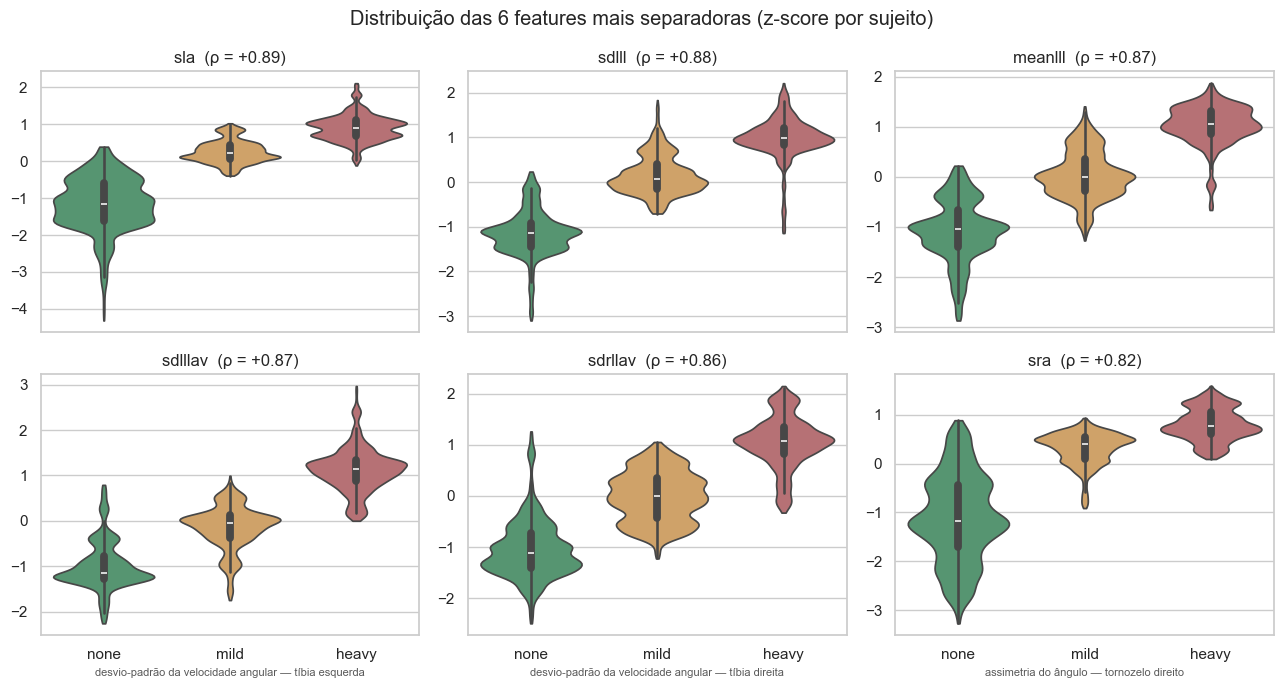

In [20]:
melhores = list(top.index[:6])

fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True)
for ax, col in zip(axes.flat, melhores):
    sns.violinplot(data=feats, x="condicao", y=col, order=list(PALETA),
                   hue="condicao", palette=PALETA, legend=False, cut=0, ax=ax)
    ax.set(title=f"{col}  (ρ = {corr[col]:+.2f})", xlabel="", ylabel="")
    ax.set_xlabel(glossario.loc[col, "descrição"], fontsize=8, color="0.35")
fig.suptitle("Distribuição das 6 features mais separadoras (z-score por sujeito)")
plt.tight_layout()

As distribuições são quase disjuntas entre `none` e as demais, e há sobreposição
entre `mild` e `heavy` — coerente com o que o baseline mostrou: a confusão é
quase toda entre classes **adjacentes**.

Vale checar se o efeito é o mesmo em todo sujeito, ou se a média esconde
comportamentos opostos:

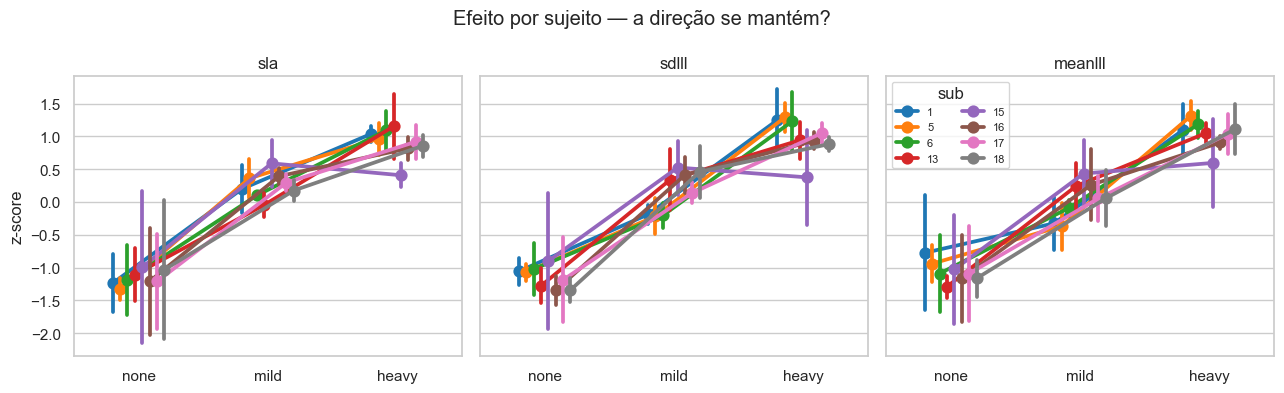

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, col in zip(axes, melhores[:3]):
    sns.pointplot(data=feats, x="condicao", y=col, hue="sub", order=list(PALETA),
                  errorbar="sd", palette="tab10", ax=ax, dodge=0.4)
    ax.set(title=col, xlabel="", ylabel="z-score")
    ax.legend_.remove() if ax.legend_ else None
axes[-1].legend(title="sub", ncol=2, fontsize=8, loc="best")
fig.suptitle("Efeito por sujeito — a direção se mantém?")
plt.tight_layout()

### Redundância entre as features

157 features derivadas dos mesmos 8 segmentos e 6 articulações têm muita
colinearidade; útil saber antes de escolher o modelo.

pares de features com |ρ| > 0.95: 13 de 12,246 (0.1%)


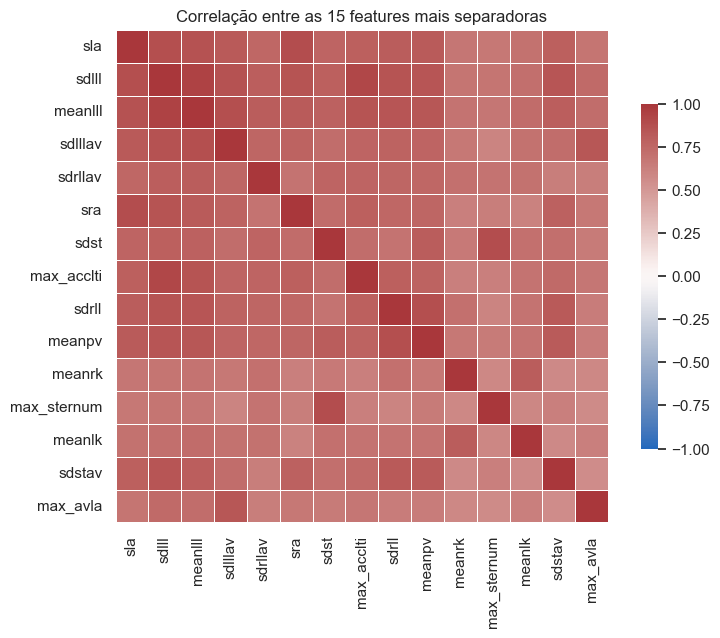

In [22]:
sub_corr = feats[list(top.index[:15])].corr(method="spearman")

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(sub_corr, cmap="vlag", center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.4, cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Correlação entre as 15 features mais separadoras")
plt.tight_layout()

todas = feats[FEATURES].corr(method="spearman").abs()
pares = todas.where(np.triu(np.ones(todas.shape), k=1).astype(bool)).stack()
print(f"pares de features com |ρ| > 0.95: {(pares > 0.95).sum():,} "
      f"de {len(pares):,} ({(pares > 0.95).mean():.1%})")

## 4. O sinal bruto

Uma gravação = uma exportação contínua do MVN a 240 Hz. Já carregamos uma na
seção 2.3 (`rec_ref`); vamos usá-la.

In [23]:
rec = rec_ref
rec

<Recording p001(sub=1) 0-2k CCW none 144,943 samples 604s>

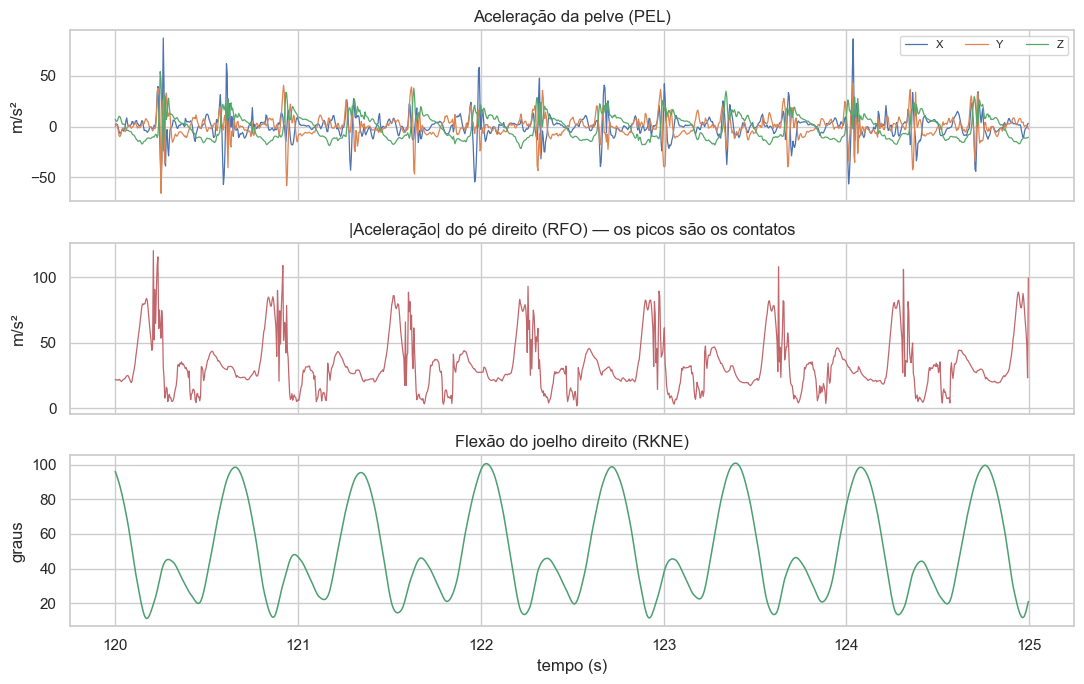

In [24]:
t = np.arange(rec.n_samples) / rec.fs
janela = (t >= 120) & (t < 125)          # 5 s no meio da corrida

fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)

for i, eixo in enumerate("XYZ"):
    axes[0].plot(t[janela], rec.acc("PEL")[janela, i], lw=0.9, label=eixo)
axes[0].set(ylabel="m/s²", title="Aceleração da pelve (PEL)")
axes[0].legend(ncol=3, fontsize=8)

axes[1].plot(t[janela], np.linalg.norm(rec.acc("RFO")[janela], axis=1),
             lw=0.9, color="#C1666B")
axes[1].set(ylabel="m/s²", title="|Aceleração| do pé direito (RFO) — os picos são os contatos")

# Coluna 2 = flexão/extensão, em graus (ver seção 2.2).
axes[2].plot(t[janela], rec.angle("RKNE")[janela, 2], lw=1.1, color="#4C9F70")
axes[2].set(xlabel="tempo (s)", ylabel="graus", title="Flexão do joelho direito (RKNE)")

plt.tight_layout()

Cerca de 7 ciclos de passada em 5 s (~0,7 s por passada), consistente com o
período medido por autocorrelação em `NOTES.md`.

distância rastreada: 1945 m em 604 s (11.6 km/h)
amostras nas voltas do paper: 81,971 de 144,943 (57%)


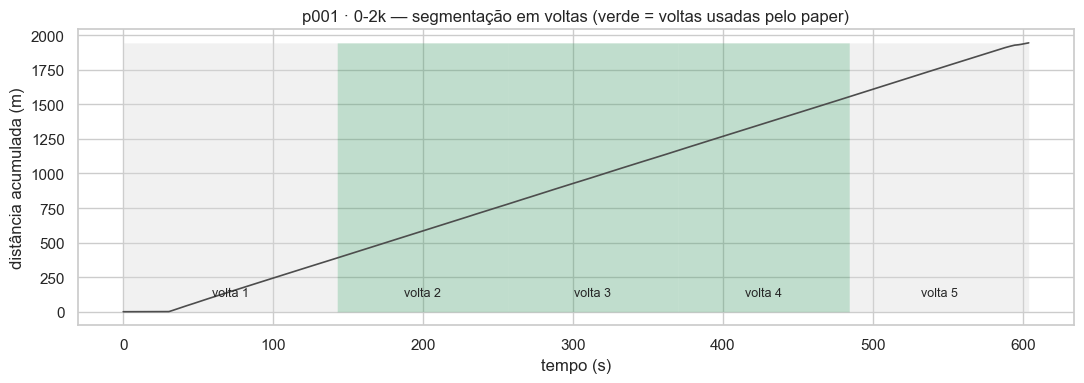

In [25]:
d = rec.distance()
voltas = rec.lap_index()
usadas = rec.paper_mask()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(t, d, color="0.3", lw=1.2)
for volta in np.unique(voltas):
    dentro = voltas == volta
    cor = "#4C9F70" if np.isin(volta, RUNS[rec.run][3]) else "0.85"
    ax.fill_between(t, 0, d.max(), where=dentro, color=cor, alpha=0.35, lw=0)
    ax.text(t[dentro].mean(), d.max() * 0.06, f"volta {volta}",
            ha="center", fontsize=9)
ax.set(xlabel="tempo (s)", ylabel="distância acumulada (m)",
       title=f"{rec.subject} · {rec.run} — segmentação em voltas "
             f"(verde = voltas usadas pelo paper)")
plt.tight_layout()

print(f"distância rastreada: {d[-1]:.0f} m em {rec.duration_s:.0f} s "
      f"({d[-1] / rec.duration_s * 3.6:.1f} km/h)")
print(f"amostras nas voltas do paper: {usadas.sum():,} de {rec.n_samples:,} "
      f"({usadas.mean():.0%})")

O MVN faz *dead reckoning* e subestima a distância real em alguns por cento
(1945 m para 2000 m nominais), por isso `lap_index()` corta em distância
**fracionária** e não num limiar fixo de 400 m.

### `none` × `heavy` no sinal bruto, mesmo sujeito

Comparando apenas as voltas que o paper usa, para não misturar aquecimento e
desaceleração.

condicao                                 heavy      none
|acc| pé direito (m/s²)        count  91164.00  81971.00
                               mean      31.38     34.30
                               std       20.83     20.99
                               min        0.01      0.75
                               25%       18.47     22.28
                               50%       26.52     29.75
                               75%       38.62     41.57
                               max      224.04    146.45
flexão joelho direito (°)      count  91164.00  81971.00
                               mean      50.67     50.81
                               std       28.24     26.99
                               min       -2.97      7.34
                               25%       27.60     28.46
                               50%       44.56     43.83
                               75%       73.60     74.87
                               max      111.32    105.99
|angvel| tíbia direita (rad/s) count  91164.00  81971.00
                               mean       6.39      6.43
                               std        3.47      3.18
                               min        0.00      0.07
                               25%        3.51      3.76
                               50%        6.21      6.42
                               75%        9.08      8.90
                               max       31.94     25.26

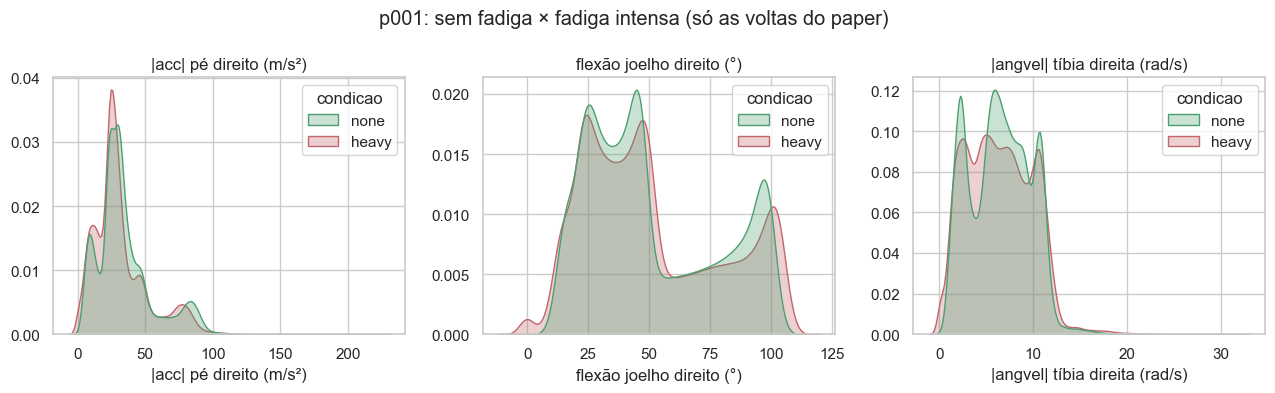

In [26]:
p001_pos = next(p for p in src.recording_paths()
                if p.stem.startswith("p001") and "postfatigue" in p.stem)
rec_pos = src.load_recording(p001_pos)

amostras = []
for r in (rec, rec_pos):
    k = r.paper_mask()
    amostras.append(pd.DataFrame({
        "|acc| pé direito (m/s²)": np.linalg.norm(r.acc("RFO")[k], axis=1),
        "flexão joelho direito (°)": r.angle("RKNE")[k, 2],
        "|angvel| tíbia direita (rad/s)": np.linalg.norm(r.angvel("RLL")[k], axis=1),
        "condicao": r.condition,
    }))
comparacao = pd.concat(amostras, ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col in zip(axes, comparacao.columns[:-1]):
    sns.kdeplot(data=comparacao, x=col, hue="condicao", palette=PALETA,
                common_norm=False, fill=True, alpha=0.3, ax=ax)
    ax.set(ylabel="", title=col)
fig.suptitle(f"{rec.subject}: sem fadiga × fadiga intensa (só as voltas do paper)")
plt.tight_layout()

comparacao.groupby("condicao", observed=True).describe().T.round(2)

Diferenças existem mas são sutis ponto a ponto — o sinal instantâneo não separa
as classes sozinho. É por isso que tanto o paper quanto o baseline agregam:
por janela de tempo ou por passada.

## 5. Passadas normalizadas no tempo

Os 45 canais estão descritos na seção 2.3.

**Ressalva importante:** as passadas cobrem as **três corridas concatenadas em
ordem cronológica** e não carregam índice de volta ou de corrida — não dá para
rotulá-las diretamente. Quando a procedência importa, use as gravações.

<Strides p001(sub=1) 45 channels x 150 pts x 2012 strides>


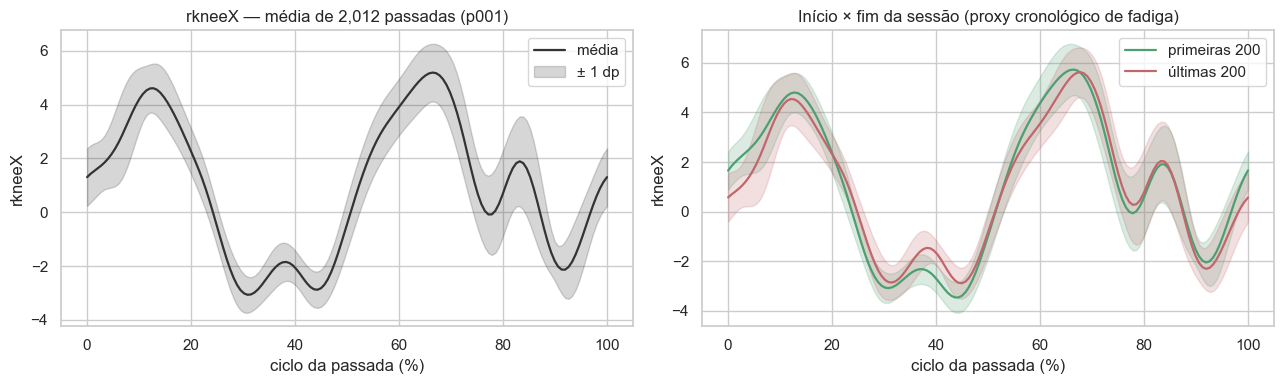

In [27]:
print(st)
canal = "rkneeX"
X = st[canal]                                   # (150 pontos, n passadas)
ciclo = np.linspace(0, 100, X.shape[0])

# Sem rótulo, o melhor proxy é a ordem cronológica: início ≈ sem fadiga,
# fim ≈ pós-fadiga. É uma aproximação, não um rótulo.
n = X.shape[1]
blocos = {"primeiras 200": X[:, :200], "últimas 200": X[:, -200:]}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(ciclo, X.mean(axis=1), color="0.2", lw=1.6, label="média")
axes[0].fill_between(ciclo, X.mean(1) - X.std(1), X.mean(1) + X.std(1),
                     color="0.2", alpha=0.2, label="± 1 dp")
axes[0].set(xlabel="ciclo da passada (%)", ylabel=canal,
            title=f"{canal} — média de {n:,} passadas ({st.subject})")
axes[0].legend()

for (nome, bloco), cor in zip(blocos.items(), ["#4C9F70", "#C1666B"]):
    axes[1].plot(ciclo, bloco.mean(axis=1), lw=1.6, color=cor, label=nome)
    axes[1].fill_between(ciclo, bloco.mean(1) - bloco.std(1),
                         bloco.mean(1) + bloco.std(1), color=cor, alpha=0.2)
axes[1].set(xlabel="ciclo da passada (%)", ylabel=canal,
            title="Início × fim da sessão (proxy cronológico de fadiga)")
axes[1].legend()
plt.tight_layout()

,sujeito,sub,n_passadas,n_canais
0,p001,1,2012,45
1,p002,5,2481,45
2,p003,6,2601,45
3,p004,13,2614,45
4,p005,15,2510,45
5,p006,16,2126,45
6,p007,17,2452,45
7,p008,18,2066,45


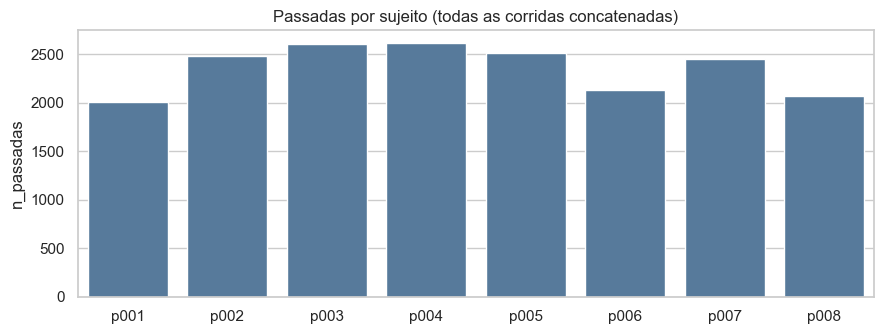

In [28]:
# Quantas passadas cada sujeito tem, e o custo de carregar tudo.
resumo = []
for s in src.iter_strides():
    resumo.append({"sujeito": s.subject, "sub": s.sub_id,
                   "n_passadas": s.n_strides, "n_canais": len(s.channels)})
resumo = pd.DataFrame(resumo)

fig, ax = plt.subplots(figsize=(9, 3.5))
sns.barplot(data=resumo, x="sujeito", y="n_passadas", color="#4C7BA6", ax=ax)
ax.set(title="Passadas por sujeito (todas as corridas concatenadas)", xlabel="")
plt.tight_layout()

resumo

Note que **p007 tem passadas da corrida pós-fadiga** mesmo sem o arquivo de
gravação correspondente — a evidência que sustenta a conclusão de que os
arquivos de passada cobrem as três corridas (ver `NOTES.md`).

## 6. Onde isto deixa o projeto

O que este notebook estabeleceu:

- **31 gravações, 8 sujeitos, 3 classes** — mas `p007` só contribui 2 classes
  nas gravações, e o token `CW`/`CCW` não é posicional.
- **As 165 colunas da `TableFeats` estão decodificadas** (seção 2.4): a
  contagem por grupo bate exatamente com os 43 + 110 + 4 = 157 do artigo, o que
  confirma o alinhamento nome↔coluna, e o índice `1…6` das features de evento
  foi verificado contra os dados.
- **`TableFeats` é separável demais** para ser levada ao pé da letra: `HR_norm`
  sozinha tem ρ ≈ 0,94 com o rótulo. A z-score por sujeito é transdutiva; um
  número de LOSO em cima dela mede calibração por usuário, não generalização
  para um usuário novo.
- **O sinal bruto instantâneo não separa as classes** — a informação está na
  agregação (janela ou passada).
- As passadas normalizadas são a representação mais limpa, mas **não têm
  rótulo**; as gravações têm, via `lap_index()` / `paper_mask()`.

Próximos passos naturais:

1. Baseline honesto sobre `TableFeats` com LOSO, comparando *com* e *sem* a
   normalização por sujeito, para quantificar quanto do desempenho vem dela.
2. Extrair features por janela do sinal bruto (o baseline anterior usou janela
   de 10 s / passo de 5 s, 69 canais × 6 descritores = 414 features) e comparar.
   O glossário da seção 2.4 dá a receita das features do artigo, caso valha
   reproduzi-las em vez de inventar as nossas.
3. Decidir o que fazer com `p007`: descartar, ou avaliar em 2 classes
   separadamente.
4. Investigar se as passadas podem ser rotuladas indiretamente (alinhando
   contagem e ordem cronológica às durações das corridas) — se der, viram o
   conjunto de treino mais limpo.